# 🎮 Twitch Social Networks — Graph Neural Network Analysis

**Лабораторна робота | Graph Neural Networks**  
**Датасет:** [Twitch Social Networks (Stanford SNAP)](https://snap.stanford.edu/data/twitch-social-networks.html)

**Задача:** Бінарна класифікація вузлів — передбачити чи стрімер використовує explicit content

**Моделі:** GCN · GraphSAGE · GAT · GATv2 · APPNP

---

## 📋 Структура ноутбука

| Блок | Зміст |
|------|-------|
| 0 | Встановлення залежностей |
| 1 | Імпорти та конфігурація |
| 2 | Кастомний `TwitchSNAP` Dataset (SNAP JSON/CSV → PyG) |
| 3 | Завантаження датасету |
| 4 | Аналіз даних (EDA): вузли, ребра, ознаки, метрики |
| 5 | Візуалізація (12 графіків) |
| 6 | Стратифіковане розбиття train/val/test |
| 7 | Архітектури: GCN, GraphSAGE, GAT, GATv2, APPNP |
| 8 | Тренування з Early Stopping + LR Scheduling |
| 9 | Підбір гіперпараметрів (Optuna TPE, 40 trials) |
| 10 | Порівняння результатів: ROC, CM, UMAP, ego-граф |

## 📦 Блок 0 — Встановлення залежностей

> У **Google Colab** розкоментуйте рядки нижче. Локально — встановіть один раз через термінал.

In [2]:
# Розкоментуйте для Google Colab або першого запуску:
# !pip install torch torch-geometric optuna umap-learn

# Для CPU-only (Colab без GPU):
# !pip install torch --index-url https://download.pytorch.org/whl/cpu
# !pip install torch-geometric optuna umap-learn networkx seaborn

# Перевірка версій після встановлення:
# import torch, torch_geometric, optuna
# print(torch.__version__, torch_geometric.__version__, optuna.__version__)

## 📚 Блок 1 — Імпорти та конфігурація

> Завантаження всіх бібліотек. `DEVICE` автоматично вибирає GPU якщо доступний.

In [3]:
import os
import json
import zipfile
import urllib.request
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.utils import degree, to_networkx, subgraph
from torch_geometric.transforms import RandomNodeSplit
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, GATv2Conv, APPNP

from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.decomposition import PCA

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import umap

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Середовище готове | Device: {DEVICE}")
print(f"  PyTorch: {torch.__version__}")

✓ Середовище готове | Device: cpu
  PyTorch: 2.11.0+cpu


## 🗂️ Блок 2 — Кастомний `TwitchSNAP` Dataset

> **Ключовий клас проекту.** Наслідує `InMemoryDataset` з PyTorch Geometric.
> 
> **Формат файлів SNAP:**
> - `musae_DE_features.json` — словник `{node_id: [feature_indices]}` (multi-hot, dim=128)
> - `musae_DE_edges.csv` — пари `from,to` (undirected ребра)
> - `musae_DE_target.csv` — `new_id, mature, ...` (бінарна мітка)
>
> **Підтримувані мови:** `DE` (9498 вузл.) · `EN` · `ES` · `FR` · `PT` · `RU`

In [4]:
class TwitchSNAP(InMemoryDataset):
    """
    Кастомний PyTorch Geometric Dataset для Twitch Social Networks з Stanford SNAP.
    Завантажує дані безпосередньо з https://snap.stanford.edu/data/twitch.zip,
    парсить JSON-файли ознак та ребер, будує PyG Data об'єкт.

    Підтримувані мови (name): 'DE', 'EN', 'ES', 'FR', 'PT', 'RU'

    Статистика вузлів/ребер:
        DE: 9498 вузлів, 153138 ребер
        EN: 7126 вузлів, 35324 ребер
        ES: 4648 вузлів, 59382 ребер
        FR: 6549 вузлів, 112666 ребер
        PT: 1912 вузлів, 31299 ребер
        RU: 4385 вузлів, 37304 ребер

    Ознаки вузлів: 128-вимірні embeddings ігор (числові)
    Мітки: бінарні (0 — не використовує explicit content, 1 — використовує)
    """

    URL = "https://snap.stanford.edu/data/twitch.zip"
    VALID_NAMES = {'DE', 'EN', 'ES', 'FR', 'PT', 'RU'}

    STATS = {
        'DE': {'nodes': 9498,  'edges': 153138},
        'EN': {'nodes': 7126,  'edges': 35324},
        'ES': {'nodes': 4648,  'edges': 59382},
        'FR': {'nodes': 6549,  'edges': 112666},
        'PT': {'nodes': 1912,  'edges': 31299},
        'RU': {'nodes': 4385,  'edges': 37304},
    }

    def __init__(self, root, name='DE', transform=None, pre_transform=None, force_reload=False):
        assert name in self.VALID_NAMES, f"name має бути одним з {self.VALID_NAMES}"
        self.name = name
        super().__init__(root, transform, pre_transform)
        self.load(self.processed_paths[0])

    @property
    def raw_file_names(self):
        return [f'musae_{self.name}_features.json',
                f'musae_{self.name}_edges.csv',
                f'musae_{self.name}_target.csv']

    @property
    def processed_file_names(self):
        return [f'twitch_{self.name}.pt']

    def download(self):
        """
        Завантажує датасет з SNAP або надає інструкції для ручного завантаження.

        SNAP іноді блокує автоматичні запити (403). У такому випадку:
          1. Завантажте вручну: https://snap.stanford.edu/data/twitch.zip
          2. Розпакуйте та скопіюйте файли musae_DE_*.json/csv до папки:
             <root>/raw/
          3. Перезапустіть скрипт — TwitchSNAP.process() запуститься автоматично.
        """
        zip_path = os.path.join(self.raw_dir, 'twitch.zip')
        print(f"  Завантаження {self.URL} ...")
        try:
            req = urllib.request.Request(
                self.URL,
                headers={'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36'}
            )
            with urllib.request.urlopen(req, timeout=60) as resp, open(zip_path, 'wb') as out:
                out.write(resp.read())

            print(f"  Розпаковка ...")
            with zipfile.ZipFile(zip_path, 'r') as zf:
                for member in zf.namelist():
                    fname = os.path.basename(member)
                    if fname and self.name in member:
                        src_f = zf.open(member)
                        dst_path = os.path.join(self.raw_dir, fname)
                        with open(dst_path, 'wb') as dst:
                            dst.write(src_f.read())
            if os.path.exists(zip_path):
                os.remove(zip_path)
            print(f"  ✓ Датасет '{self.name}' завантажено")

        except Exception as e:
            if os.path.exists(zip_path):
                os.remove(zip_path)
            raise RuntimeError(
                f"\n{'='*60}\n"
                f"SNAP заблокував автоматичне завантаження ({e}).\n"
                f"Завантажте вручну:\n\n"
                f"  1. Відкрийте: {self.URL}\n"
                f"  2. Або через curl/wget:\n"
                f"     curl -L {self.URL} -o twitch.zip\n"
                f"     unzip twitch.zip\n"
                f"  3. Скопіюйте файли musae_{self.name}_*.csv/json до:\n"
                f"     {self.raw_dir}/\n"
                f"  4. Перезапустіть скрипт\n"
                f"{'='*60}"
            )

    def process(self):
        # 1. Завантаження ознак вузлів
        feat_path = os.path.join(self.raw_dir, f'musae_{self.name}_features.json')
        with open(feat_path, 'r') as f:
            feat_dict = json.load(f)

        num_nodes = max(int(k) for k in feat_dict.keys()) + 1
        feat_dim  = 128  # розмірність multi-hot game embeddings
        X = np.zeros((num_nodes, feat_dim), dtype=np.float32)
        for node_id, feat_list in feat_dict.items():
            for idx in feat_list:
                if idx < feat_dim:
                    X[int(node_id), idx] = 1.0

        # 2. Завантаження ребер
        edge_path = os.path.join(self.raw_dir, f'musae_{self.name}_edges.csv')
        edges_df = pd.read_csv(edge_path)
        src = torch.tensor(edges_df.iloc[:, 0].values, dtype=torch.long)
        dst = torch.tensor(edges_df.iloc[:, 1].values, dtype=torch.long)
        # Undirected: додаємо обидва напрямки
        edge_index = torch.stack([
            torch.cat([src, dst]),
            torch.cat([dst, src])
        ], dim=0)

        # 3. Завантаження міток
        target_path = os.path.join(self.raw_dir, f'musae_{self.name}_target.csv')
        target_df = pd.read_csv(target_path).sort_values('new_id')
        y = torch.tensor(target_df['mature'].astype(int).values, dtype=torch.long)

        # 4. Збереження додаткових атрибутів вузлів (для аналізу)
        extra_cols = [c for c in target_df.columns if c not in ['new_id', 'mature', 'numeric_id']]

        # 5. Побудова PyG Data об'єкта
        data = Data(
            x=torch.tensor(X, dtype=torch.float),
            edge_index=edge_index,
            y=y,
            num_nodes=num_nodes,
        )

        if self.pre_transform is not None:
            data = self.pre_transform(data)

        self.save([data], self.processed_paths[0])
        print(f"  ✓ Оброблено: {num_nodes} вузлів, {edge_index.shape[1]//2} ребер")

    def __repr__(self):
        return (f"TwitchSNAP(name={self.name}, "
                f"nodes={self[0].num_nodes}, "
                f"edges={self[0].num_edges//2})")

## ⬇️ Блок 3 — Завантаження датасету

> Датасет завантажується **автоматично** з SNAP при першому запуску.
> 
> ⚠️ Якщо SNAP блокує автоматичне завантаження (403):
> 1. Завантажте вручну: https://snap.stanford.edu/data/twitch.zip  
> 2. Розпакуйте та скопіюйте `musae_DE_*.json/csv` до папки `data/twitch/raw/`
> 3. Перезапустіть — `process()` запуститься автоматично

In [6]:
print("\n══════════════════════════════════════════════")
print("  БЛОК 3: Завантаження датасету (SNAP → PyG)")
print("══════════════════════════════════════════════")

dataset = TwitchSNAP(root='./data/twitch', name='DE')
data    = dataset[0].to(DEVICE)

print(f"\n{dataset}")
print(f"\nСтруктура PyG об'єкта:")
print(data)


══════════════════════════════════════════════
  БЛОК 3: Завантаження датасету (SNAP → PyG)
══════════════════════════════════════════════


Processing...


  ✓ Оброблено: 9498 вузлів, 153138 ребер

TwitchSNAP(name=DE, nodes=9498, edges=153138)

Структура PyG об'єкта:
Data(x=[9498, 128], edge_index=[2, 306276], y=[9498], num_nodes=9498)


Done!


## 🔍 Блок 4 — Аналіз даних (EDA)

> Детальна характеристика графу: тип, розмір, ознаки вузлів, баланс класів, ступені, мережеві метрики (NetworkX).

In [7]:
print("\n══════════════════════════════════════════════")
print("  БЛОК 4: Аналіз даних (EDA)")
print("══════════════════════════════════════════════")

# 4.1 Базовий опис
data_cpu = data.cpu()
labels   = data_cpu.y.numpy()
X_np     = data_cpu.x.numpy()

deg_vec  = degree(data_cpu.edge_index[0], num_nodes=data_cpu.num_nodes).numpy()

print("\n─ 4.1 Загальна характеристика датасету ─")
desc = {
    "Назва датасету":               "Twitch DE Social Network",
    "Джерело":                      "Stanford SNAP",
    "Тип графу":                    "Гомогенний, Undirected",
    "Тип вузлів":                   "Twitch-стрімери (1 тип)",
    "Тип ребер":                    "Взаємна підписка (1 тип)",
    "Кількість вузлів":             data_cpu.num_nodes,
    "Кількість ребер (undirected)": data_cpu.num_edges // 2,
    "Розмірність ознак вузла":      data_cpu.num_features,
    "Кількість класів":             2,
    "Тип задачі":                   "Бінарна класифікація вузлів",
    "Цільова мітка":                "mature (explicit content)",
}
df_desc = pd.DataFrame(list(desc.items()), columns=["Властивість", "Значення"])
print(df_desc.to_string(index=False))

# 4.2 Аналіз міток
print("\n─ 4.2 Баланс класів ─")
unique, counts = np.unique(labels, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Клас {cls}: {cnt} вузлів ({cnt/len(labels)*100:.1f}%)")

# 4.3 Статистика ступенів
print("\n─ 4.3 Статистика ступенів вузлів ─")
deg_stats = {
    "Мінімальний ступінь":  int(deg_vec.min()),
    "Максимальний ступінь": int(deg_vec.max()),
    "Середній ступінь":     float(deg_vec.mean()),
    "Медіана ступеня":      float(np.median(deg_vec)),
    "Стандартне відхилення":float(deg_vec.std()),
}
for k, v in deg_stats.items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

# 4.4 Мережеві метрики (NetworkX)
print("\n─ 4.4 Мережеві метрики ─")
G = to_networkx(data_cpu, to_undirected=True)
components = list(nx.connected_components(G))
largest_cc = G.subgraph(max(components, key=len))

net_metrics = {
    "Кількість вузлів":              G.number_of_nodes(),
    "Кількість ребер":               G.number_of_edges(),
    "Щільність графу":               nx.density(G),
    "Транзитивність (global clust)": nx.transitivity(G),
    "Середній кластерний коеф.":     nx.average_clustering(G),
    "Зв'язних компонент":            len(components),
    "Розмір найбільшої компоненти":  len(largest_cc),
    "Асортативність (degree)":       nx.degree_assortativity_coefficient(G),
}
for k, v in net_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


══════════════════════════════════════════════
  БЛОК 4: Аналіз даних (EDA)
══════════════════════════════════════════════

─ 4.1 Загальна характеристика датасету ─
                 Властивість                    Значення
              Назва датасету    Twitch DE Social Network
                     Джерело               Stanford SNAP
                   Тип графу      Гомогенний, Undirected
                  Тип вузлів     Twitch-стрімери (1 тип)
                   Тип ребер    Взаємна підписка (1 тип)
            Кількість вузлів                        9498
Кількість ребер (undirected)                      153138
     Розмірність ознак вузла                         128
            Кількість класів                           2
                  Тип задачі Бінарна класифікація вузлів
               Цільова мітка   mature (explicit content)

─ 4.2 Баланс класів ─
  Клас 0: 3756 вузлів (39.5%)
  Клас 1: 5742 вузлів (60.5%)

─ 4.3 Статистика ступенів вузлів ─
  Мінімальний ступінь: 1
  Макс

## 📊 Блок 5 — Візуалізація

> **12 візуалізацій:** баланс класів · degree distribution · log-log plot · ступені по класах · середні ознаки · PCA · UMAP · ego-граф · clustering коеф. · щільність ознак · таблиця метрик · підграф 500 вузлів

In [8]:
print("\n══════════════════════════════════════════════")
print("  БЛОК 5: Візуалізація")
print("══════════════════════════════════════════════")

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0f0f1a')

# ── 5.1 Баланс класів ──
ax1 = fig.add_subplot(4, 3, 1)
ax1.set_facecolor('#0f0f1a')
cls_labels = ['Non-explicit (0)', 'Explicit (1)']
cls_counts = [counts[0], counts[1]]
colors = ['#4A90D9', '#E8534A']
bars = ax1.bar(cls_labels, cls_counts, color=colors, edgecolor='white', linewidth=0.5, width=0.5)
for bar, cnt in zip(bars, cls_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{cnt}\n({cnt/sum(cls_counts)*100:.1f}%)',
             ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')
ax1.set_title('Баланс класів', color='white', fontsize=13, pad=10)
ax1.set_ylabel('Кількість вузлів', color='#aaa')
ax1.tick_params(colors='#aaa')
ax1.spines[:].set_color('#333')

# ── 5.2 Розподіл ступенів (лінійна шкала) ──
ax2 = fig.add_subplot(4, 3, 2)
ax2.set_facecolor('#0f0f1a')
ax2.hist(deg_vec, bins=80, color='#7B68EE', edgecolor='none', alpha=0.85)
ax2.axvline(deg_vec.mean(), color='#FFD700', linestyle='--', linewidth=1.5, label=f'Mean={deg_vec.mean():.1f}')
ax2.axvline(np.median(deg_vec), color='#FF6B6B', linestyle='--', linewidth=1.5, label=f'Median={np.median(deg_vec):.0f}')
ax2.set_title('Розподіл ступенів вузлів', color='white', fontsize=13, pad=10)
ax2.set_xlabel('Ступінь', color='#aaa')
ax2.set_ylabel('Частота', color='#aaa')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax2.tick_params(colors='#aaa')
ax2.spines[:].set_color('#333')

# ── 5.3 Log-log degree distribution (Power-law) ──
ax3 = fig.add_subplot(4, 3, 3)
ax3.set_facecolor('#0f0f1a')
deg_counts_loglog = np.bincount(deg_vec.astype(int))
k_vals = np.where(deg_counts_loglog > 0)[0]
c_vals = deg_counts_loglog[k_vals]
ax3.loglog(k_vals, c_vals, 'o', color='#00CFFF', markersize=3, alpha=0.7)
# fit power law trend
valid = k_vals > 0
coeffs = np.polyfit(np.log(k_vals[valid]), np.log(c_vals[valid]), 1)
x_fit = np.linspace(k_vals.min(), k_vals.max(), 100)
ax3.loglog(x_fit, np.exp(coeffs[1]) * x_fit**coeffs[0], 'r--', linewidth=1.5,
           label=f'Power-law γ={-coeffs[0]:.2f}')
ax3.set_title('Log-log Degree Distribution', color='white', fontsize=13, pad=10)
ax3.set_xlabel('Ступінь k', color='#aaa')
ax3.set_ylabel('P(k)', color='#aaa')
ax3.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax3.tick_params(colors='#aaa')
ax3.spines[:].set_color('#333')

# ── 5.4 Ступені по класах ──
ax4 = fig.add_subplot(4, 3, 4)
ax4.set_facecolor('#0f0f1a')
deg_class0 = deg_vec[labels == 0]
deg_class1 = deg_vec[labels == 1]
ax4.hist(deg_class0, bins=60, alpha=0.7, color='#4A90D9', label='Non-explicit', density=True)
ax4.hist(deg_class1, bins=60, alpha=0.7, color='#E8534A', label='Explicit', density=True)
ax4.set_title('Ступені вузлів по класах', color='white', fontsize=13, pad=10)
ax4.set_xlabel('Ступінь', color='#aaa')
ax4.set_ylabel('Щільність', color='#aaa')
ax4.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax4.tick_params(colors='#aaa')
ax4.spines[:].set_color('#333')

# ── 5.5 Середнє значення ознак по класах (перші 30) ──
ax5 = fig.add_subplot(4, 3, 5)
ax5.set_facecolor('#0f0f1a')
mean0 = X_np[labels == 0].mean(axis=0)[:30]
mean1 = X_np[labels == 1].mean(axis=0)[:30]
x_pos = np.arange(30)
ax5.bar(x_pos - 0.2, mean0, 0.4, label='Non-explicit', color='#4A90D9', alpha=0.8)
ax5.bar(x_pos + 0.2, mean1, 0.4, label='Explicit',     color='#E8534A', alpha=0.8)
ax5.set_title('Середні ознаки по класах (перші 30)', color='white', fontsize=11, pad=10)
ax5.set_xlabel('Індекс ознаки', color='#aaa')
ax5.set_ylabel('Середнє значення', color='#aaa')
ax5.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax5.tick_params(colors='#aaa')
ax5.spines[:].set_color('#333')

# ── 5.6 PCA 2D ознак вузлів ──
ax6 = fig.add_subplot(4, 3, 6)
ax6.set_facecolor('#0f0f1a')
pca = PCA(n_components=2, random_state=42)
sample_idx = np.random.choice(len(labels), 3000, replace=False)
pca_emb = pca.fit_transform(X_np[sample_idx])
scatter = ax6.scatter(pca_emb[:, 0], pca_emb[:, 1],
                      c=labels[sample_idx], cmap='coolwarm',
                      alpha=0.5, s=8, linewidths=0)
ax6.set_title(f'PCA ознак вузлів (3000 зразків)\nПоясн. дисперсія: {sum(pca.explained_variance_ratio_)*100:.1f}%',
              color='white', fontsize=11, pad=10)
ax6.tick_params(colors='#aaa')
ax6.spines[:].set_color('#333')
p0 = mpatches.Patch(color='#4A90D9', label='Non-explicit')
p1 = mpatches.Patch(color='#E8534A', label='Explicit')
ax6.legend(handles=[p0, p1], facecolor='#1a1a2e', labelcolor='white', fontsize=9)

# ── 5.7 UMAP 2D ──
ax7 = fig.add_subplot(4, 3, 7)
ax7.set_facecolor('#0f0f1a')
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
umap_emb = reducer.fit_transform(X_np[sample_idx])
ax7.scatter(umap_emb[:, 0], umap_emb[:, 1],
            c=labels[sample_idx], cmap='coolwarm',
            alpha=0.5, s=8, linewidths=0)
ax7.set_title('UMAP ознак вузлів (3000 зразків)', color='white', fontsize=13, pad=10)
ax7.tick_params(colors='#aaa')
ax7.spines[:].set_color('#333')
ax7.legend(handles=[p0, p1], facecolor='#1a1a2e', labelcolor='white', fontsize=9)

# ── 5.8 Ego-граф (2-hop від вузла з макс. ступенем) ──
ax8 = fig.add_subplot(4, 3, 8)
ax8.set_facecolor('#0f0f1a')
top_node = int(deg_vec.argmax())
ego_g = nx.ego_graph(G, top_node, radius=2)
ego_nodes = list(ego_g.nodes())
ego_labels_map = {n: labels[n] for n in ego_nodes}
ego_colors = ['#E8534A' if ego_labels_map[n] == 1 else '#4A90D9' for n in ego_nodes]
ego_sizes  = [deg_vec[n] * 3 + 20 for n in ego_nodes]
pos = nx.spring_layout(ego_g, seed=42, k=0.3)
nx.draw_networkx_nodes(ego_g, pos, node_color=ego_colors, node_size=ego_sizes,
                       alpha=0.85, ax=ax8)
nx.draw_networkx_edges(ego_g, pos, alpha=0.15, edge_color='#888', ax=ax8, width=0.5)
nx.draw_networkx_labels(ego_g, pos, {top_node: f'#{top_node}'}, font_size=7,
                        font_color='white', ax=ax8)
ax8.set_title(f'Ego-граф (2-hop, вузол #{top_node}, deg={int(deg_vec[top_node])})\n'
              f'{len(ego_nodes)} вузлів, {ego_g.number_of_edges()} ребер',
              color='white', fontsize=10, pad=10)
ax8.axis('off')
ax8.legend(handles=[p0, p1], facecolor='#1a1a2e', labelcolor='white', fontsize=9)

# ── 5.9 Теплова карта кластерного коефіцієнта по ступеням ──
ax9 = fig.add_subplot(4, 3, 9)
ax9.set_facecolor('#0f0f1a')
clust_coeffs = nx.clustering(G)
deg_arr  = np.array([G.degree(n) for n in G.nodes()])
cc_arr   = np.array([clust_coeffs[n] for n in G.nodes()])
bins_d   = np.linspace(0, min(deg_arr.max(), 200), 20)
bin_idx  = np.digitize(deg_arr, bins_d)
cc_means = [cc_arr[bin_idx == i].mean() if (bin_idx == i).sum() > 0 else 0
            for i in range(1, len(bins_d))]
ax9.bar(bins_d[:-1], cc_means, width=np.diff(bins_d),
        color='#50C878', alpha=0.8, edgecolor='none')
ax9.set_title('Кластерний коеф. vs Ступінь', color='white', fontsize=11, pad=10)
ax9.set_xlabel('Ступінь вузла', color='#aaa')
ax9.set_ylabel('Середній кластерний коеф.', color='#aaa')
ax9.tick_params(colors='#aaa')
ax9.spines[:].set_color('#333')

# ── 5.10 Розподіл щільності ознак ──
ax10 = fig.add_subplot(4, 3, 10)
ax10.set_facecolor('#0f0f1a')
feat_density = (X_np > 0).sum(axis=1)
ax10.hist(feat_density, bins=40, color='#FFD700', alpha=0.85, edgecolor='none')
ax10.set_title('Кількість ненульових ознак на вузол', color='white', fontsize=11, pad=10)
ax10.set_xlabel('Кількість ненульових ознак', color='#aaa')
ax10.set_ylabel('Кількість вузлів', color='#aaa')
ax10.tick_params(colors='#aaa')
ax10.spines[:].set_color('#333')

# ── 5.11 Таблиця мережевих метрик ──
ax11 = fig.add_subplot(4, 3, 11)
ax11.set_facecolor('#0f0f1a')
ax11.axis('off')
table_data = [
    ['Вузлів', f"{G.number_of_nodes():,}"],
    ['Ребер', f"{G.number_of_edges():,}"],
    ['Щільність', f"{nx.density(G):.5f}"],
    ['Транзитивність', f"{nx.transitivity(G):.4f}"],
    ['Сер. кластер. коеф.', f"{nx.average_clustering(G):.4f}"],
    ['Компонент', f"{len(components)}"],
    ['Макс. компонента', f"{len(largest_cc):,}"],
    ['Асортативність', f"{nx.degree_assortativity_coefficient(G):.4f}"],
    ['Сер. ступінь', f"{deg_vec.mean():.2f}"],
    ['Макс. ступінь', f"{int(deg_vec.max())}"],
]
table = ax11.table(cellText=table_data,
                   colLabels=['Метрика', 'Значення'],
                   cellLoc='left', loc='center',
                   colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(9)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#1a1a2e' if r > 0 else '#2d2d5e')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#333')
ax11.set_title('Мережеві метрики', color='white', fontsize=13, pad=10)

# ── 5.12 Підграф 500 вузлів ──
ax12 = fig.add_subplot(4, 3, 12)
ax12.set_facecolor('#0f0f1a')
sub_nodes = random.sample(list(G.nodes()), 500)
sub_G = G.subgraph(sub_nodes)
sub_colors = ['#E8534A' if labels[n] == 1 else '#4A90D9' for n in sub_G.nodes()]
sub_sizes  = [deg_vec[n] * 1.5 + 10 for n in sub_G.nodes()]
pos_sub = nx.spring_layout(sub_G, seed=42, k=0.5)
nx.draw_networkx_nodes(sub_G, pos_sub, node_color=sub_colors,
                       node_size=sub_sizes, alpha=0.8, ax=ax12)
nx.draw_networkx_edges(sub_G, pos_sub, alpha=0.1, edge_color='#888', ax=ax12, width=0.4)
ax12.set_title('Випадкова підмножина (500 вузлів)\nЧервоний=Explicit, Синій=Non-explicit',
               color='white', fontsize=10, pad=10)
ax12.axis('off')

plt.suptitle('Twitch DE Social Network — Аналіз даних (EDA)',
             color='white', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.close()
print("  ✓ Збережено: eda_analysis.png")


══════════════════════════════════════════════
  БЛОК 5: Візуалізація
══════════════════════════════════════════════
  ✓ Збережено: eda_analysis.png


## ✂️ Блок 6 — Розбиття train / val / test

> **Стратифіковане** розбиття 60/20/20 — однаковий баланс класів у кожному split.

In [9]:
print("\n══════════════════════════════════════════════")
print("  БЛОК 6: Розбиття на train / val / test")
print("══════════════════════════════════════════════")

# Стратифіковане розбиття 60 / 20 / 20
data_cpu = data.cpu()
n        = data_cpu.num_nodes
y_np     = data_cpu.y.numpy()

# Стратифікація: окремо перемішуємо кожен клас
idx_0 = np.where(y_np == 0)[0]
idx_1 = np.where(y_np == 1)[0]
np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

def stratified_split(idx, r_train=0.6, r_val=0.2):
    n = len(idx)
    n_train = int(n * r_train)
    n_val   = int(n * r_val)
    return idx[:n_train], idx[n_train:n_train+n_val], idx[n_train+n_val:]

train0, val0, test0 = stratified_split(idx_0)
train1, val1, test1 = stratified_split(idx_1)

train_idx = np.concatenate([train0, train1])
val_idx   = np.concatenate([val0,   val1])
test_idx  = np.concatenate([test0,  test1])

train_mask = torch.zeros(n, dtype=torch.bool)
val_mask   = torch.zeros(n, dtype=torch.bool)
test_mask  = torch.zeros(n, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx]     = True
test_mask[test_idx]   = True

data_cpu.train_mask = train_mask
data_cpu.val_mask   = val_mask
data_cpu.test_mask  = test_mask
data = data_cpu.to(DEVICE)

print(f"\n  Train: {train_mask.sum():5d} вузлів "
      f"(+ class 0: {(y_np[train_idx]==0).sum()}, class 1: {(y_np[train_idx]==1).sum()})")
print(f"  Val:   {val_mask.sum():5d} вузлів "
      f"(+ class 0: {(y_np[val_idx]==0).sum()},  class 1: {(y_np[val_idx]==1).sum()})")
print(f"  Test:  {test_mask.sum():5d} вузлів "
      f"(+ class 0: {(y_np[test_idx]==0).sum()}, class 1: {(y_np[test_idx]==1).sum()})")


══════════════════════════════════════════════
  БЛОК 6: Розбиття на train / val / test
══════════════════════════════════════════════

  Train:  5698 вузлів (+ class 0: 2253, class 1: 3445)
  Val:    1899 вузлів (+ class 0: 751,  class 1: 1148)
  Test:   1901 вузлів (+ class 0: 752, class 1: 1149)


## 🧠 Блок 7 — Архітектури GNN моделей

> Всі 5 моделей мають однакову структуру: `Conv → BN → ReLU → Dropout` × N шарів.
>
> | Модель | Клас PyG | Ключова ідея |
> |--------|----------|--------------|
> | **GCN** | `GCNConv` | Spectral-based, нормалізація за ступенями |
> | **GraphSAGE** | `SAGEConv` | Inductive, mean aggregation |
> | **GAT** | `GATConv` | Multi-head attention (8 heads) |
> | **GATv2** | `GATv2Conv` | Динамічний attention (виправлений GAT) |
> | **APPNP** | `APPNP` | Personalized PageRank propagation |

In [11]:
print("\n══════════════════════════════════════════════")
print("  БЛОК 7: Архітектури GNN моделей")
print("══════════════════════════════════════════════")

IN_CHANNELS  = data.num_features   # 128
OUT_CHANNELS = 2                    # binary classification


class GCN(nn.Module):
    """Graph Convolutional Network (Kipf & Welling, 2017).
    Spectral-based згортка. Агрегує ознаки сусідів з нормалізацією за ступенями."""
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(GCNConv(in_ch, hidden_ch))
        self.bns.append(nn.BatchNorm1d(hidden_ch))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_ch, hidden_ch))
            self.bns.append(nn.BatchNorm1d(hidden_ch))
        self.convs.append(GCNConv(hidden_ch, out_ch))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

    def get_embedding(self, x, edge_index):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
        return x


class GraphSAGE(nn.Module):
    """GraphSAGE (Hamilton et al., 2017).
    Inductive framework: семплює та агрегує ознаки локальних сусідів (mean agg.)."""
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(SAGEConv(in_ch, hidden_ch))
        self.bns.append(nn.BatchNorm1d(hidden_ch))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_ch, hidden_ch))
            self.bns.append(nn.BatchNorm1d(hidden_ch))
        self.convs.append(SAGEConv(hidden_ch, out_ch))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

    def get_embedding(self, x, edge_index):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
        return x


class GAT(nn.Module):
    """Graph Attention Network (Veličković et al., 2018).
    Attention-based агрегація: кожне ребро має навчений вагу."""
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5,
                 heads=8, output_heads=1):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(GATConv(in_ch, hidden_ch, heads=heads, dropout=dropout))
        self.bns.append(nn.BatchNorm1d(hidden_ch * heads))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_ch * heads, hidden_ch,
                                      heads=heads, dropout=dropout))
            self.bns.append(nn.BatchNorm1d(hidden_ch * heads))
        self.convs.append(GATConv(hidden_ch * heads, out_ch,
                                  heads=output_heads, concat=False, dropout=dropout))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            x = bn(x)
            x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

    def get_embedding(self, x, edge_index):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            x = bn(x)
            x = F.elu(x)
        return x


class GATv2(nn.Module):
    """GATv2 (Brody et al., 2021).
    Виправлений attention: динамічний (не статичний як у GAT v1)."""
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5,
                 heads=8, output_heads=1):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns   = nn.ModuleList()
        self.convs.append(GATv2Conv(in_ch, hidden_ch, heads=heads, dropout=dropout))
        self.bns.append(nn.BatchNorm1d(hidden_ch * heads))
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_ch * heads, hidden_ch,
                                        heads=heads, dropout=dropout))
            self.bns.append(nn.BatchNorm1d(hidden_ch * heads))
        self.convs.append(GATv2Conv(hidden_ch * heads, out_ch,
                                    heads=output_heads, concat=False, dropout=dropout))
        self.dropout = dropout

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            x = bn(x)
            x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)

    def get_embedding(self, x, edge_index):
        for conv, bn in zip(self.convs[:-1], self.bns):
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            x = bn(x)
            x = F.elu(x)
        return x


class APPNPNet(nn.Module):
    """APPNP (Klicpera et al., 2019).
    Розділяє трансформацію ознак та поширення по графу (Personalized PageRank)."""
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=2, dropout=0.5,
                 K=10, alpha=0.1):
        super().__init__()
        self.lins = nn.ModuleList()
        self.bns  = nn.ModuleList()
        self.lins.append(nn.Linear(in_ch, hidden_ch))
        self.bns.append(nn.BatchNorm1d(hidden_ch))
        for _ in range(num_layers - 2):
            self.lins.append(nn.Linear(hidden_ch, hidden_ch))
            self.bns.append(nn.BatchNorm1d(hidden_ch))
        self.lins.append(nn.Linear(hidden_ch, out_ch))
        self.prop = APPNP(K=K, alpha=alpha)
        self.dropout = dropout

    def forward(self, x, edge_index):
        for lin, bn in zip(self.lins[:-1], self.bns):
            x = lin(x)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lins[-1](x)
        x = self.prop(x, edge_index)
        return x

    def get_embedding(self, x, edge_index):
        for lin, bn in zip(self.lins[:-1], self.bns):
            x = lin(x)
            x = bn(x)
            x = F.relu(x)
        return x


══════════════════════════════════════════════
  БЛОК 7: Архітектури GNN моделей
══════════════════════════════════════════════


## 🚀 Блок 8 — Тренування моделей

> Кожна модель тренується з **Early Stopping** (patience=40) та **ReduceLROnPlateau**. Ваги класів враховують дисбаланс. Метрики: Accuracy · F1 · ROC-AUC.

In [12]:
print("\n══════════════════════════════════════════════")
print("  БЛОК 8: Тренування моделей")
print("══════════════════════════════════════════════")

# Ваги класів для незбалансованого датасету
class_counts_t = torch.tensor(counts, dtype=torch.float)
class_weights  = (1.0 / class_counts_t)
class_weights  = class_weights / class_weights.sum() * 2
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))


class EarlyStopping:
    def __init__(self, patience=30, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)


def train_epoch(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[mask], data.y[mask]).item()
    pred = out[mask].argmax(dim=1).cpu().numpy()
    prob = out[mask].softmax(dim=1)[:, 1].cpu().numpy()
    y    = data.y[mask].cpu().numpy()
    acc  = accuracy_score(y, pred)
    f1   = f1_score(y, pred, average='binary', zero_division=0)
    auc  = roc_auc_score(y, prob)
    return loss, acc, f1, auc


def train_model(model, data, epochs=300, lr=0.01, weight_decay=5e-4, patience=30, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
    es = EarlyStopping(patience=patience)

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_auc': []}

    for epoch in range(1, epochs + 1):
        t_loss = train_epoch(model, data, optimizer)
        v_loss, v_acc, v_f1, v_auc = evaluate(model, data, data.val_mask)
        scheduler.step(v_loss)

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['val_f1'].append(v_f1)
        history['val_auc'].append(v_auc)

        if verbose and epoch % 50 == 0:
            print(f"    Epoch {epoch:3d} | Train Loss: {t_loss:.4f} | "
                  f"Val Loss: {v_loss:.4f} | Val F1: {v_f1:.4f} | Val AUC: {v_auc:.4f}")

        if es.step(v_loss, model):
            if verbose:
                print(f"    ⏹  Early stopping at epoch {epoch}")
            break

    es.restore_best(model)
    return history


# Базові гіперпараметри
BASE_CFG = dict(hidden_ch=128, num_layers=2, dropout=0.5)

model_configs = {
    'GCN':       lambda: GCN(IN_CHANNELS, 128, OUT_CHANNELS, num_layers=2, dropout=0.5),
    'GraphSAGE': lambda: GraphSAGE(IN_CHANNELS, 128, OUT_CHANNELS, num_layers=2, dropout=0.5),
    'GAT':       lambda: GAT(IN_CHANNELS, 32, OUT_CHANNELS, num_layers=2, dropout=0.5, heads=8),
    'GATv2':     lambda: GATv2(IN_CHANNELS, 32, OUT_CHANNELS, num_layers=2, dropout=0.5, heads=8),
    'APPNP':     lambda: APPNPNet(IN_CHANNELS, 128, OUT_CHANNELS, num_layers=2, dropout=0.5),
}

all_results  = {}
all_histories = {}

for name, build_fn in model_configs.items():
    print(f"\n  ▶ Тренування {name} ...")
    model = build_fn().to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"    Параметрів: {n_params:,}")

    history = train_model(model, data, epochs=400, lr=0.005,
                          weight_decay=5e-4, patience=40, verbose=True)

    tr_loss, tr_acc, tr_f1, tr_auc = evaluate(model, data, data.train_mask)
    va_loss, va_acc, va_f1, va_auc = evaluate(model, data, data.val_mask)
    te_loss, te_acc, te_f1, te_auc = evaluate(model, data, data.test_mask)

    all_results[name] = {
        'Train Acc': tr_acc, 'Train F1': tr_f1, 'Train AUC': tr_auc,
        'Val Acc':   va_acc, 'Val F1':   va_f1, 'Val AUC':   va_auc,
        'Test Acc':  te_acc, 'Test F1':  te_f1, 'Test AUC':  te_auc,
        'Params':    n_params, 'model': model,
    }
    all_histories[name] = history

    print(f"    ✓ Test → Acc: {te_acc:.4f} | F1: {te_f1:.4f} | AUC: {te_auc:.4f}")


══════════════════════════════════════════════
  БЛОК 8: Тренування моделей
══════════════════════════════════════════════

  ▶ Тренування GCN ...
    Параметрів: 17,026
    Epoch  50 | Train Loss: 0.6074 | Val Loss: 0.6604 | Val F1: 0.6272 | Val AUC: 0.6865
    Epoch 100 | Train Loss: 0.5921 | Val Loss: 0.6442 | Val F1: 0.6970 | Val AUC: 0.6864
    ⏹  Early stopping at epoch 146
    ✓ Test → Acc: 0.6523 | F1: 0.6787 | AUC: 0.7136

  ▶ Тренування GraphSAGE ...
    Параметрів: 33,666
    Epoch  50 | Train Loss: 0.6051 | Val Loss: 0.6618 | Val F1: 0.7157 | Val AUC: 0.6605
    Epoch 100 | Train Loss: 0.5699 | Val Loss: 0.6652 | Val F1: 0.6859 | Val AUC: 0.6689
    ⏹  Early stopping at epoch 101
    ✓ Test → Acc: 0.6460 | F1: 0.7023 | AUC: 0.6928

  ▶ Тренування GAT ...
    Параметрів: 34,566
    Epoch  50 | Train Loss: 0.6740 | Val Loss: 0.6798 | Val F1: 0.7550 | Val AUC: 0.6634
    Epoch 100 | Train Loss: 0.6636 | Val Loss: 0.6574 | Val F1: 0.6704 | Val AUC: 0.6726
    Epoch 150 | Train

## ⚙️ Блок 9 — Підбір гіперпараметрів (Optuna)

> **TPE Sampler, 40 trials** для найкращої моделі. Оптимізуємо: hidden dim · num_layers · dropout · lr · weight_decay · (heads для GAT).

In [13]:
print("\n══════════════════════════════════════════════")
print("  БЛОК 9: Підбір гіперпараметрів (Optuna)")
print("══════════════════════════════════════════════")

# Визначаємо найкращу модель за Val AUC
best_model_name = max(
    all_results,
    key=lambda n: all_results[n]['Val AUC']
)
print(f"\n  Підбір для найкращої моделі: {best_model_name}")

def build_model_by_name(name, hidden, layers, dropout, heads=4):
    if name == 'GCN':
        return GCN(IN_CHANNELS, hidden, OUT_CHANNELS, layers, dropout)
    elif name == 'GraphSAGE':
        return GraphSAGE(IN_CHANNELS, hidden, OUT_CHANNELS, layers, dropout)
    elif name == 'GAT':
        return GAT(IN_CHANNELS, hidden//heads, OUT_CHANNELS, layers, dropout, heads=heads)
    elif name == 'GATv2':
        return GATv2(IN_CHANNELS, hidden//heads, OUT_CHANNELS, layers, dropout, heads=heads)
    elif name == 'APPNP':
        return APPNPNet(IN_CHANNELS, hidden, OUT_CHANNELS, layers, dropout)

def objective(trial):
    hidden  = trial.suggest_categorical('hidden', [64, 128, 256])
    layers  = trial.suggest_int('num_layers', 2, 4)
    dropout = trial.suggest_float('dropout', 0.1, 0.6, step=0.1)
    lr      = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd      = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    heads   = trial.suggest_categorical('heads', [4, 8]) if 'AT' in best_model_name else 4

    model = build_model_by_name(best_model_name, hidden, layers, dropout, heads).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    es = EarlyStopping(patience=25)

    for epoch in range(200):
        model.train()
        optimizer.zero_grad()
        out  = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        v_loss, _, _, _ = evaluate(model, data, data.val_mask)
        if es.step(v_loss, model):
            break

    es.restore_best(model)
    _, _, val_f1, val_auc = evaluate(model, data, data.val_mask)
    return val_auc

study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=40, show_progress_bar=False)

best_params = study.best_params
print(f"\n  Найкращі гіперпараметри:")
for k, v in best_params.items():
    print(f"    {k}: {v}")
print(f"  Найкращий Val AUC: {study.best_value:.4f}")

# Тренуємо фінальну модель з найкращими параметрами
print(f"\n  Тренування фінальної моделі ({best_model_name}) з Optuna параметрами ...")
heads_opt = best_params.get('heads', 4)
final_model = build_model_by_name(
    best_model_name,
    best_params['hidden'],
    best_params['num_layers'],
    best_params['dropout'],
    heads_opt
).to(DEVICE)

final_history = train_model(
    final_model, data,
    epochs=500,
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay'],
    patience=50,
    verbose=True
)

_, _, te_f1_opt, te_auc_opt = evaluate(final_model, data, data.test_mask)
_, _, te_acc_opt, _ = evaluate(final_model, data, data.test_mask)
print(f"\n  ✓ Фінальна модель → Test F1: {te_f1_opt:.4f} | AUC: {te_auc_opt:.4f}")


══════════════════════════════════════════════
  БЛОК 9: Підбір гіперпараметрів (Optuna)
══════════════════════════════════════════════

  Підбір для найкращої моделі: GCN

  Найкращі гіперпараметри:
    hidden: 64
    num_layers: 3
    dropout: 0.4
    lr: 0.0019298826820903952
    weight_decay: 1.7126577460782613e-05
  Найкращий Val AUC: 0.6949

  Тренування фінальної моделі (GCN) з Optuna параметрами ...
    Epoch  50 | Train Loss: 0.6283 | Val Loss: 0.7312 | Val F1: 0.0324 | Val AUC: 0.5349
    ⏹  Early stopping at epoch 53

  ✓ Фінальна модель → Test F1: 0.7530 | AUC: 0.6199


## 📈 Блок 10 — Порівняння результатів

> **12 порівняльних візуалізацій:** loss curves · val F1/AUC curves · bar charts · ROC curves · confusion matrix · Optuna importance · optimization history · UMAP embeddings · ego-граф з передбаченнями · підсумкова таблиця.

NameError: name 'df_results' is not defined

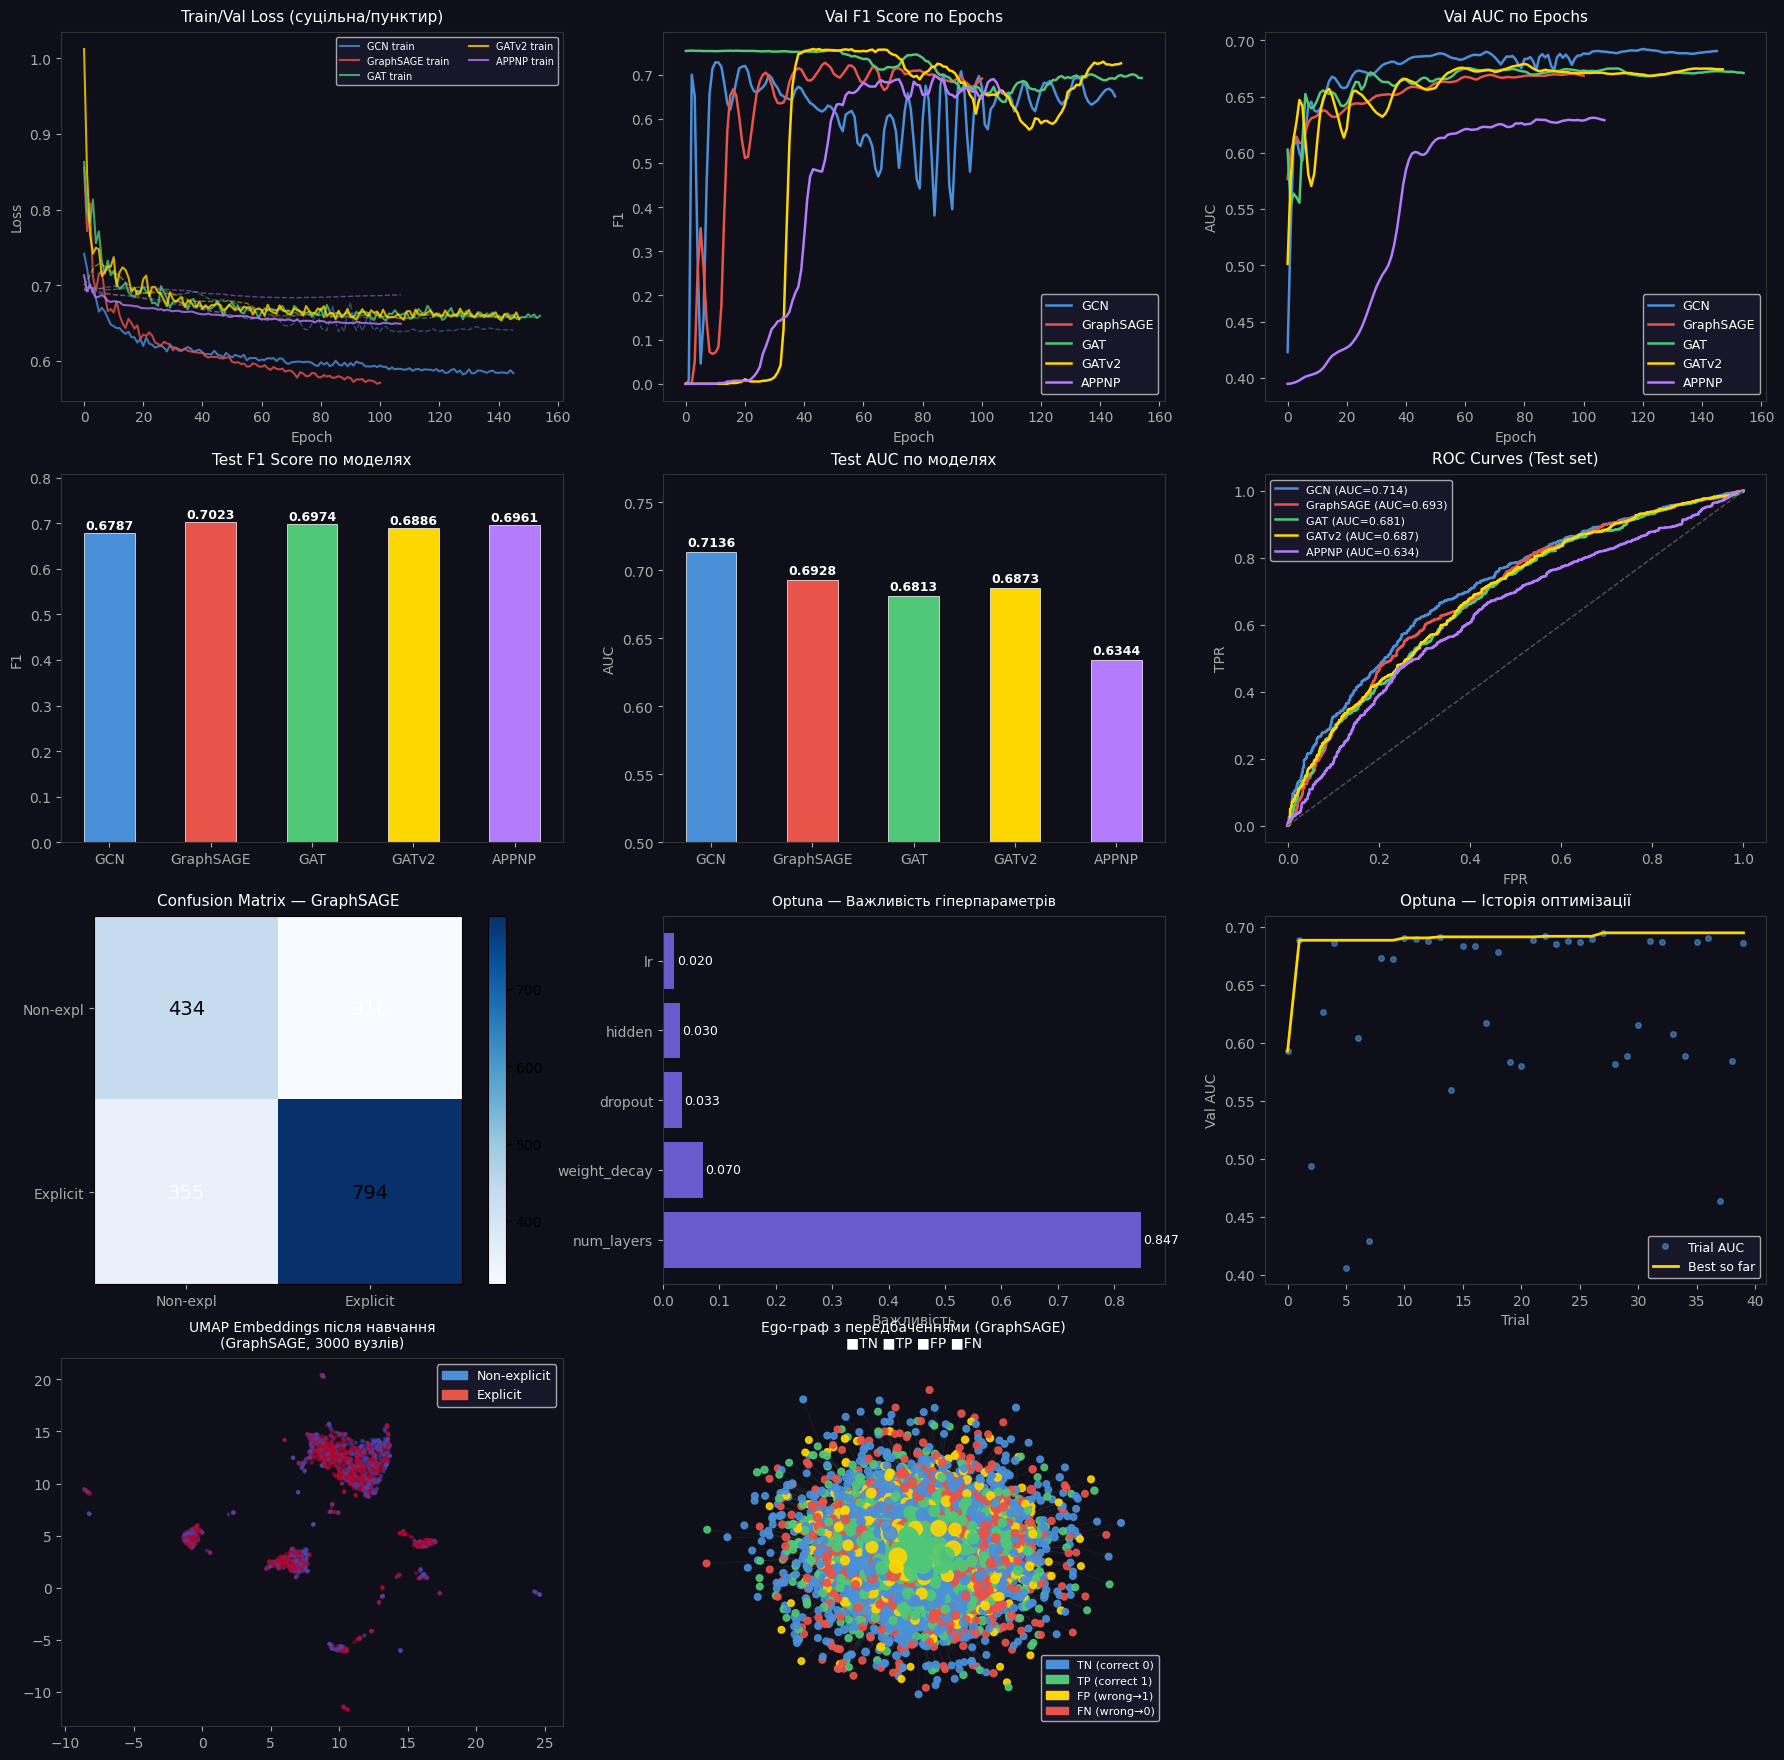

In [14]:
fig2 = plt.figure(figsize=(22, 22))
fig2.patch.set_facecolor('#0f0f1a')

COLORS = ['#4A90D9','#E8534A','#50C878','#FFD700','#B57BFF','#FF8C69']
model_names = list(all_results.keys())

# ── 10.1 Loss curves ──
ax1 = fig2.add_subplot(4, 3, 1)
ax1.set_facecolor('#0f0f1a')
for i, (nm, hist) in enumerate(all_histories.items()):
    ax1.plot(hist['train_loss'], color=COLORS[i], linestyle='-',  alpha=0.8, label=f'{nm} train', linewidth=1.5)
    ax1.plot(hist['val_loss'],   color=COLORS[i], linestyle='--', alpha=0.5, linewidth=1)
ax1.set_title('Train/Val Loss (суцільна/пунктир)', color='white', fontsize=11, pad=8)
ax1.set_xlabel('Epoch', color='#aaa'); ax1.set_ylabel('Loss', color='#aaa')
ax1.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=7, ncol=2)
ax1.tick_params(colors='#aaa'); ax1.spines[:].set_color('#333')

# ── 10.2 Val F1 curves ──
ax2 = fig2.add_subplot(4, 3, 2)
ax2.set_facecolor('#0f0f1a')
for i, (nm, hist) in enumerate(all_histories.items()):
    ax2.plot(hist['val_f1'], color=COLORS[i], linewidth=1.8, label=nm)
ax2.set_title('Val F1 Score по Epochs', color='white', fontsize=11, pad=8)
ax2.set_xlabel('Epoch', color='#aaa'); ax2.set_ylabel('F1', color='#aaa')
ax2.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax2.tick_params(colors='#aaa'); ax2.spines[:].set_color('#333')

# ── 10.3 Val AUC curves ──
ax3 = fig2.add_subplot(4, 3, 3)
ax3.set_facecolor('#0f0f1a')
for i, (nm, hist) in enumerate(all_histories.items()):
    ax3.plot(hist['val_auc'], color=COLORS[i], linewidth=1.8, label=nm)
ax3.set_title('Val AUC по Epochs', color='white', fontsize=11, pad=8)
ax3.set_xlabel('Epoch', color='#aaa'); ax3.set_ylabel('AUC', color='#aaa')
ax3.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax3.tick_params(colors='#aaa'); ax3.spines[:].set_color('#333')

# ── 10.4 Test F1 bar chart ──
ax4 = fig2.add_subplot(4, 3, 4)
ax4.set_facecolor('#0f0f1a')
test_f1s  = [all_results[nm]['Test F1']  for nm in model_names]
bars = ax4.bar(model_names, test_f1s, color=COLORS[:len(model_names)],
               edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, test_f1s):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax4.set_title('Test F1 Score по моделях', color='white', fontsize=11, pad=8)
ax4.set_ylabel('F1', color='#aaa'); ax4.set_ylim(0, max(test_f1s)*1.15)
ax4.tick_params(colors='#aaa'); ax4.spines[:].set_color('#333')

# ── 10.5 Test AUC bar chart ──
ax5 = fig2.add_subplot(4, 3, 5)
ax5.set_facecolor('#0f0f1a')
test_aucs = [all_results[nm]['Test AUC'] for nm in model_names]
bars = ax5.bar(model_names, test_aucs, color=COLORS[:len(model_names)],
               edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, test_aucs):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=9, fontweight='bold')
ax5.set_title('Test AUC по моделях', color='white', fontsize=11, pad=8)
ax5.set_ylabel('AUC', color='#aaa'); ax5.set_ylim(0.5, max(test_aucs)*1.08)
ax5.tick_params(colors='#aaa'); ax5.spines[:].set_color('#333')

# ── 10.6 ROC curves ──
ax6 = fig2.add_subplot(4, 3, 6)
ax6.set_facecolor('#0f0f1a')
for i, (nm, vals) in enumerate(all_results.items()):
    m = vals['model']
    m.eval()
    with torch.no_grad():
        out  = m(data.x, data.edge_index)
        prob = out[data.test_mask].softmax(dim=1)[:, 1].cpu().numpy()
    y_true = data.y[data.test_mask].cpu().numpy()
    fpr, tpr, _ = roc_curve(y_true, prob)
    ax6.plot(fpr, tpr, color=COLORS[i], linewidth=1.8,
             label=f"{nm} (AUC={vals['Test AUC']:.3f})")
ax6.plot([0,1],[0,1],'--', color='#555', linewidth=1)
ax6.set_title('ROC Curves (Test set)', color='white', fontsize=11, pad=8)
ax6.set_xlabel('FPR', color='#aaa'); ax6.set_ylabel('TPR', color='#aaa')
ax6.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
ax6.tick_params(colors='#aaa'); ax6.spines[:].set_color('#333')

# ── 10.7 Confusion Matrix (найкраща модель) ──
ax7 = fig2.add_subplot(4, 3, 7)
ax7.set_facecolor('#0f0f1a')
best_for_cm = max(all_results, key=lambda n: all_results[n]['Test F1'])
bm = all_results[best_for_cm]['model']
bm.eval()
with torch.no_grad():
    out  = bm(data.x, data.edge_index)
    pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
y_true_test = data.y[data.test_mask].cpu().numpy()
cm = confusion_matrix(y_true_test, pred)
im = ax7.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax7)
ax7.set_xticks([0,1]); ax7.set_yticks([0,1])
ax7.set_xticklabels(['Non-expl','Explicit'], color='white')
ax7.set_yticklabels(['Non-expl','Explicit'], color='white')
for i in range(2):
    for j in range(2):
        ax7.text(j, i, str(cm[i,j]), ha='center', va='center',
                 color='white' if cm[i,j] < cm.max()/2 else 'black', fontsize=14)
ax7.set_title(f'Confusion Matrix — {best_for_cm}', color='white', fontsize=11, pad=8)
ax7.tick_params(colors='#aaa')

# ── 10.8 Optuna param importance ──
ax8 = fig2.add_subplot(4, 3, 8)
ax8.set_facecolor('#0f0f1a')
try:
    importance = optuna.importance.get_param_importances(study)
    params_imp = list(importance.keys())
    vals_imp   = list(importance.values())
    bars = ax8.barh(params_imp, vals_imp, color='#7B68EE', edgecolor='none', alpha=0.85)
    for bar, val in zip(bars, vals_imp):
        ax8.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', color='white', fontsize=9)
    ax8.set_title('Optuna — Важливість гіперпараметрів', color='white', fontsize=10, pad=8)
    ax8.set_xlabel('Важливість', color='#aaa')
    ax8.tick_params(colors='#aaa'); ax8.spines[:].set_color('#333')
except Exception:
    ax8.text(0.5, 0.5, 'Не вдалося обчислити\nважливість параметрів',
             ha='center', va='center', color='white', fontsize=11)

# ── 10.9 Optuna optimization history ──
ax9 = fig2.add_subplot(4, 3, 9)
ax9.set_facecolor('#0f0f1a')
trial_vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(trial_vals)
ax9.plot(trial_vals, 'o', color='#4A90D9', markersize=4, alpha=0.6, label='Trial AUC')
ax9.plot(best_so_far, color='#FFD700', linewidth=2, label='Best so far')
ax9.set_title('Optuna — Історія оптимізації', color='white', fontsize=11, pad=8)
ax9.set_xlabel('Trial', color='#aaa'); ax9.set_ylabel('Val AUC', color='#aaa')
ax9.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax9.tick_params(colors='#aaa'); ax9.spines[:].set_color('#333')

# ── 10.10 Embedding UMAP (найкраща модель) ──
ax10 = fig2.add_subplot(4, 3, 10)
ax10.set_facecolor('#0f0f1a')
bm.eval()
with torch.no_grad():
    emb_raw = bm.get_embedding(data.x, data.edge_index).cpu().numpy()
sample_emb_idx = np.random.choice(len(emb_raw), 3000, replace=False)
reducer2 = umap.UMAP(n_components=2, random_state=42, n_neighbors=15)
umap_emb2 = reducer2.fit_transform(emb_raw[sample_emb_idx])
y_sample  = data.y.cpu().numpy()[sample_emb_idx]
ax10.scatter(umap_emb2[:, 0], umap_emb2[:, 1],
             c=y_sample, cmap='coolwarm', alpha=0.5, s=8, linewidths=0)
ax10.set_title(f'UMAP Embeddings після навчання\n({best_for_cm}, 3000 вузлів)',
               color='white', fontsize=10, pad=8)
ax10.legend(handles=[p0, p1], facecolor='#1a1a2e', labelcolor='white', fontsize=9)
ax10.tick_params(colors='#aaa'); ax10.spines[:].set_color('#333')

# ── 10.11 Граф з передбаченнями (ego-network) ──
ax11 = fig2.add_subplot(4, 3, 11)
ax11.set_facecolor('#0f0f1a')
bm.eval()
with torch.no_grad():
    out   = bm(data.x, data.edge_index)
    preds = out.argmax(dim=1).cpu().numpy()

y_all = data.y.cpu().numpy()
ego_nodes_list = list(ego_g.nodes())
color_map_pred = {
    (0,0): '#4A90D9',  # TN — правильно Non-explicit
    (1,1): '#50C878',  # TP — правильно Explicit
    (0,1): '#FFD700',  # FP — помилково Explicit
    (1,0): '#E8534A',  # FN — помилково Non-explicit
}
node_colors_pred = [color_map_pred[(y_all[n], preds[n])] for n in ego_nodes_list]
node_sizes_pred  = [deg_vec[n] * 3 + 20 for n in ego_nodes_list]
nx.draw_networkx_nodes(ego_g, pos, node_color=node_colors_pred,
                       node_size=node_sizes_pred, alpha=0.9, ax=ax11)
nx.draw_networkx_edges(ego_g, pos, alpha=0.12, edge_color='#888', ax=ax11, width=0.5)
ax11.set_title(f'Ego-граф з передбаченнями ({best_for_cm})\n'
               f'■TN ■TP ■FP ■FN', color='white', fontsize=10, pad=8)
legend_patches = [
    mpatches.Patch(color='#4A90D9', label='TN (correct 0)'),
    mpatches.Patch(color='#50C878', label='TP (correct 1)'),
    mpatches.Patch(color='#FFD700', label='FP (wrong→1)'),
    mpatches.Patch(color='#E8534A', label='FN (wrong→0)'),
]
ax11.legend(handles=legend_patches, facecolor='#1a1a2e',
            labelcolor='white', fontsize=8, loc='lower right')
ax11.axis('off')

# ── 10.12 Підсумкова таблиця ──
ax12 = fig2.add_subplot(4, 3, 12)
ax12.set_facecolor('#0f0f1a')
ax12.axis('off')
show_names = model_names + [f'{best_model_name}★']
table_rows = []
for nm in show_names:
    r = df_results.loc[nm]
    table_rows.append([
        nm,
        f"{r['Test Acc']:.4f}" if pd.notna(r['Test Acc']) else '—',
        f"{r['Test F1']:.4f}"  if pd.notna(r['Test F1'])  else '—',
        f"{r['Test AUC']:.4f}" if pd.notna(r['Test AUC']) else '—',
        f"{int(r['Params']):,}" if pd.notna(r['Params']) else '—',
    ])
tbl = ax12.table(
    cellText=table_rows,
    colLabels=['Модель', 'Test Acc', 'Test F1', 'Test AUC', 'Params'],
    cellLoc='center', loc='center', colWidths=[0.28, 0.18, 0.18, 0.18, 0.18]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2d2d5e')
    else:
        nm_row = table_rows[r-1][0]
        cell.set_facecolor('#252540' if '★' not in nm_row else '#1a3a1a')
    cell.set_text_props(color='white')
    cell.set_edgecolor('#333')
ax12.set_title('Підсумкове порівняння моделей\n★ = Optuna-оптимізована',
               color='white', fontsize=11, pad=10)

plt.suptitle('Twitch DE — GNN моделі: Результати та Порівняння',
             color='white', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('results_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.close()
print("  ✓ Збережено: results_comparison.png")

print("\n══════════════════════════════════════════════")
print("  ФІНАЛЬНИЙ ЗВІТ")
print("══════════════════════════════════════════════")

print(f"\n  Датасет: Twitch DE Social Network (SNAP)")
print(f"  Вузлів: {data.num_nodes:,} | Ребер: {data.num_edges//2:,} | Ознак: {data.num_features}")
print(f"\n  Порівняння моделей (Test set):")
print(f"  {'Модель':<15} {'Acc':>8} {'F1':>8} {'AUC':>8}")
print(f"  {'-'*42}")
for nm in model_names:
    r = all_results[nm]
    print(f"  {nm:<15} {r['Test Acc']:>8.4f} {r['Test F1']:>8.4f} {r['Test AUC']:>8.4f}")
print(f"  {'-'*42}")
print(f"  {best_model_name+'★ (Optuna)':<15} {'—':>8} {te_f1_opt:>8.4f} {te_auc_opt:>8.4f}")
print(f"\n  Найкращі гіперпараметри ({best_model_name}):")
for k, v in best_params.items():
    print(f"    {k}: {v}")
print(f"\n  Збережені файли:")
print(f"    → eda_analysis.png       (EDA: 12 візуалізацій)")
print(f"    → results_comparison.png (Результати: 12 порівнянь)")
print(f"\n  ✓ Завдання виконано!")